# Imports

In [1]:
import os
import time
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from scipy import stats
from collections import Counter
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

Using Colab cache for faster access to the 'human-face-emotions' dataset.


In [3]:
original_path = f"{path}/Data"
desired_emotions = ["Angry", "Happy", "Sad"]

# EDA

## Crear dataset con las imagenes de las emociones a clasificar

In [4]:
# Crear una lista con las rutas de las imágenes de las emociones deseadas
data = []
for emotion in desired_emotions:
    emotion_path = os.path.join(original_path, emotion)
    if os.path.exists(emotion_path):
        for imagen in os.listdir(emotion_path):
            # Guardamos la ruta completa de la imagen y su etiqueta (emoción)
            completed_path = os.path.join(emotion_path, imagen)
            data.append({"Path": completed_path, "Emotion": emotion})

# Convertimos a DataFrame de Pandas
df_raw = pd.DataFrame(data)

# Mezclar el dataset (shuffle)
df_raw = df_raw.sample(frac=1).reset_index(drop=True)

print(df_raw.head())

                                                Path Emotion
0  /kaggle/input/human-face-emotions/Data/Angry/1...   Angry
1  /kaggle/input/human-face-emotions/Data/Angry/1...   Angry
2  /kaggle/input/human-face-emotions/Data/Sad/455...     Sad
3  /kaggle/input/human-face-emotions/Data/Sad/356...     Sad
4  /kaggle/input/human-face-emotions/Data/Sad/310...     Sad


## Entender distribucion inicial

In [5]:
frecuency = df_raw['Emotion'].value_counts()
representation = (df_raw['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_raw)}\n')
print(resumen)

Total de imágenes: 41140

         Frecuencia  Representacion (%)
Emotion                                
Happy         18439               44.82
Sad           12553               30.51
Angry         10148               24.67


## Balancear clases recortando

In [6]:
# Cantidad mínima de imágenes
min_imgs = df_raw['Emotion'].value_counts().min()

# Agrupar por emocion y tomar muestra aleatoria de ese tamano minimo
df_balanced = df_raw.groupby('Emotion').sample(n=min_imgs, random_state=42).reset_index(drop=True)

In [7]:
frecuency = df_balanced['Emotion'].value_counts()
representation = (df_balanced['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_balanced)}\n')
print(resumen)

Total de imágenes: 30444

         Frecuencia  Representacion (%)
Emotion                                
Angry         10148               33.33
Happy         10148               33.33
Sad           10148               33.33


## Estandarizacion de formatos

In [8]:
X_data = []
y_label = []

total_img = len(df_balanced)

print(f"Iniciando el procesamiento de {total_img} imágenes...")

start_time = time.time()
omitted_img = 0

for idx, fila in df_balanced.iterrows():
    try:
        img = Image.open(fila['Path'])

        if img.mode != 'L':
            img = img.convert('L')

        if img.size != (48, 48):
            img = img.resize((48, 48), Image.Resampling.LANCZOS)

        matriz = np.array(img, dtype=np.float32)
        tensor_normalizado = matriz / 255.0
        tensor_final = np.expand_dims(tensor_normalizado, axis=-1)

        X_data.append(tensor_final)
        y_label.append(fila['Emotion'])
    except Exception as e:
        omitted_img += 1
        print(f"Advertencia: Error al cargar {fila['Path']}: {e}")
        continue

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_img:
        porcentaje = ((idx + 1) / total_img) * 100
        print(f" Procesadas: {idx + 1}/{total_img} [{porcentaje:.1f}%]")

# Conversión final a NumPy
X = np.array(X_data, dtype=np.float32)
y = np.array(y_label)

final_time = time.time()

total_time = final_time - start_time
minutes = int(total_time // 60)
seconds = int(total_time % 60)

print(f"Tiempo total de ejecución: {minutes} min {seconds} seg")
print(f"Imágenes procesadas exitosamente: {X.shape}")
print(f"Imágenes omitidas por error: {omitted_img}")
print(f"Etiquetas guardadas: {y.shape}")

Iniciando el procesamiento de 30444 imágenes...
 Procesadas: 2000/30444 [6.6%]
 Procesadas: 4000/30444 [13.1%]
 Procesadas: 6000/30444 [19.7%]
 Procesadas: 8000/30444 [26.3%]
 Procesadas: 10000/30444 [32.8%]
 Procesadas: 12000/30444 [39.4%]
 Procesadas: 14000/30444 [46.0%]
 Procesadas: 16000/30444 [52.6%]
 Procesadas: 18000/30444 [59.1%]
 Procesadas: 20000/30444 [65.7%]
 Procesadas: 22000/30444 [72.3%]
 Procesadas: 24000/30444 [78.8%]
 Procesadas: 26000/30444 [85.4%]
 Procesadas: 28000/30444 [92.0%]
 Procesadas: 30000/30444 [98.5%]
 Procesadas: 30444/30444 [100.0%]
Tiempo total de ejecución: 4 min 9 seg
Imágenes procesadas exitosamente: (30444, 48, 48, 1)
Imágenes omitidas por error: 0
Etiquetas guardadas: (30444,)


In [9]:
# Estadísticas del Tensor X (Imágenes preprocesadas)
print("TENSOR DE ENTRADA / IMÁGENES (X):")
print(f"  Estructura total (Shape): {X.shape}")
print(f"  Cantidad total de muestras: {X.shape[0]} imágenes")
print(f"  Dimensión de cada imagen: {X.shape[1]} x {X.shape[2]} píxeles")
print(f"  Canales de color ajustados: {X.shape[3]} (1 = Escala de grises pura)")
print(f"  Tipo de datos en memoria (Dtype): {X.dtype}")
print(f"  Rango de los píxeles: Mínimo = {X.min():.2f} | Máximo = {X.max():.2f}")
print(f"  Peso total en memoria RAM: {X.nbytes / (1024**2):.2f} MB")

# Estadísticas del Vector y (Etiquetas/Clases)
print("\nVECTOR DE SALIDA / ETIQUETAS (y):")
print(f"  Estructura total (Shape): {y.shape}")
print(f"  Tipo de dato (Dtype): {y.dtype}")

TENSOR DE ENTRADA / IMÁGENES (X):
  Estructura total (Shape): (30444, 48, 48, 1)
  Cantidad total de muestras: 30444 imágenes
  Dimensión de cada imagen: 48 x 48 píxeles
  Canales de color ajustados: 1 (1 = Escala de grises pura)
  Tipo de datos en memoria (Dtype): float32
  Rango de los píxeles: Mínimo = 0.00 | Máximo = 1.00
  Peso total en memoria RAM: 267.57 MB

VECTOR DE SALIDA / ETIQUETAS (y):
  Estructura total (Shape): (30444,)
  Tipo de dato (Dtype): <U5


## Intesidad por Pixel

In [10]:
intensidades_promedio = np.mean(X, axis=(1, 2, 3))

df_eda = pd.DataFrame({
    'Intensidad Promedio': intensidades_promedio,
    'Emocion': y
})

palette = {'Happy': '#1f77b4', 'Sad': '#ff7f0e', 'Angry': '#2ca02c'}

In [11]:
def get_stats_with_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return pd.Series({
        'Cantidad': len(series),
        'Promedio': series.mean(),
        'Mediana': series.median(),
        'Desv. Estándar': series.std(),
        'Mínimo': series.min(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'Máximo': series.max(),
        'Atípicos (Outliers)': len(outliers),
        '% Atípicos': (len(outliers) / len(series)) * 100
    })

print("ANÁLISIS ESTADÍSTICO POR EMOCIÓN:\n")
stats_df = df_eda.groupby('Emocion')['Intensidad Promedio'].apply(get_stats_with_outliers).unstack().reset_index()
stats_df.rename(columns={'Emocion': 'Emoción'}, inplace=True)

print(stats_df.to_string(index=False, formatters={
    'Cantidad': '{:,.0f}'.format,
    'Promedio': '{:.4f}'.format,
    'Mediana': '{:.4f}'.format,
    'Desv. Estándar': '{:.4f}'.format,
    'Mínimo': '{:.4f}'.format,
    'Q1 (25%)': '{:.4f}'.format,
    'Q3 (75%)': '{:.4f}'.format,
    'Máximo': '{:.4f}'.format,
    'Atípicos (Outliers)': '{:,.0f}'.format,
    '% Atípicos': '{:.2f}%'.format
}))

ANÁLISIS ESTADÍSTICO POR EMOCIÓN:

Emoción Cantidad Promedio Mediana Desv. Estándar Mínimo Q1 (25%) Q3 (75%) Máximo Atípicos (Outliers) % Atípicos
  Angry   10,148   0.4948  0.4978         0.1302 0.0000   0.4125   0.5851 0.9603                  75      0.74%
  Happy   10,148   0.5049  0.4999         0.1247 0.0000   0.4205   0.5876 0.9607                  56      0.55%
    Sad   10,148   0.4721  0.4717         0.1323 0.0000   0.3836   0.5627 0.9582                  60      0.59%


In [12]:
grupo_happy = df_eda[df_eda['Emocion'] == 'Happy']['Intensidad Promedio']
grupo_sad = df_eda[df_eda['Emocion'] == 'Sad']['Intensidad Promedio']
grupo_angry = df_eda[df_eda['Emocion'] == 'Angry']['Intensidad Promedio']

f_val, p_val = stats.f_oneway(grupo_happy, grupo_sad, grupo_angry)
print("\nPRUEBA ESTADÍSTICA COMPARATIVA (ANOVA de una vía):")
print(f"  Estadístico F: {f_val:.4f}")
print(f"  Valor p: {p_val:.4e}")


PRUEBA ESTADÍSTICA COMPARATIVA (ANOVA de una vía):
  Estadístico F: 172.2227
  Valor p: 0.0000e+00


# Particionamiento de Datos

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_encoded, num_classes=3)
y_val_cat = to_categorical(y_val_encoded, num_classes=3)
y_test_cat = to_categorical(y_test_encoded, num_classes=3)

print("Estructuras de los conjuntos de datos en memoria:")
print(f"  Entrenamiento: X_train = {X_train.shape} | y_train_cat = {y_train_cat.shape}")
print(f"  Validación:    X_val   = {X_val.shape}   | y_val_cat   = {y_val_cat.shape}")
print(f"  Prueba:        X_test  = {X_test.shape}  | y_test_cat  = {y_test_cat.shape}")
print(f"Clases mapeadas y orden de índices: {list(label_encoder.classes_)}")

Estructuras de los conjuntos de datos en memoria:
  Entrenamiento: X_train = (21310, 48, 48, 1) | y_train_cat = (21310, 3)
  Validación:    X_val   = (4567, 48, 48, 1)   | y_val_cat   = (4567, 3)
  Prueba:        X_test  = (4567, 48, 48, 1)  | y_test_cat  = (4567, 3)
Clases mapeadas y orden de índices: [np.str_('Angry'), np.str_('Happy'), np.str_('Sad')]


In [14]:
print("Distribución estratificada de clases por conjunto:")
for nombre, y_set in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    conteo = Counter(y_set)
    total = len(y_set)
    print(f"\n{nombre} (Total: {total}):")
    for clase, cantidad in conteo.items():
        porcentaje = (cantidad / total) * 100
        print(f"  {clase}: {cantidad} imágenes ({porcentaje:.2f}%)")

Distribución estratificada de clases por conjunto:

Entrenamiento (Total: 21310):
  Sad: 7103 imágenes (33.33%)
  Angry: 7104 imágenes (33.34%)
  Happy: 7103 imágenes (33.33%)

Validación (Total: 4567):
  Happy: 1522 imágenes (33.33%)
  Sad: 1523 imágenes (33.35%)
  Angry: 1522 imágenes (33.33%)

Prueba (Total: 4567):
  Sad: 1522 imágenes (33.33%)
  Happy: 1523 imágenes (33.35%)
  Angry: 1522 imágenes (33.33%)


In [15]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num = encoder.transform(y_val)
y_test_num = encoder.transform(y_test)

y_train_oh = to_categorical(y_train_num, num_classes=3)
y_val_oh = to_categorical(y_val_num, num_classes=3)
y_test_oh = to_categorical(y_test_num, num_classes=3)

print(f"y_train_oh shape: {y_train_oh.shape}, dtype: {y_train_oh.dtype}")
print(f"Ejemplo: {y_train_oh[0]}")

y_train_oh shape: (21310, 3), dtype: float64
Ejemplo: [0. 0. 1.]


## Adaptación a 3 canales (RGB) para pesos pre-entrenados

In [16]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

print(f"Nueva forma de X_train: {X_train.shape}")
print(f"Nueva forma de X_val:   {X_val.shape}")
print(f"Nueva forma de X_test:  {X_test.shape}")


Nueva forma de X_train: (21310, 48, 48, 3)
Nueva forma de X_val:   (4567, 48, 48, 3)
Nueva forma de X_test:  (4567, 48, 48, 3)


# Data Augmentation

In [17]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Modelo

In [18]:
from tensorflow.keras.layers import Resizing, Lambda

def resnet_preprocess(x):
    return preprocess_input(x * 255.0)

# Backbone pre-entrenado (ResNet50)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling=None
)

base_model.trainable = False

inputs = Input(shape=(48, 48, 3))
x = Resizing(224, 224)(inputs)
x = Lambda(resnet_preprocess)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.6)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs, name="face2emotion_resnet50")


def freeze_up_to(base_model, unfreeze_from_prefix):
    base_model.trainable = True
    unfreezing = False
    for layer in base_model.layers:
        if layer.name.startswith(unfreeze_from_prefix):
            unfreezing = True
        if unfreezing and not isinstance(layer, BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
model.summary()

Model: "face2emotion_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compilacion del modelo

In [20]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)

## Callbacks

In [21]:
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, total_epochs, class_names):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.class_names = class_names
        self.total_epochs = total_epochs
        self.history_f1 = []
        self.pbar = None

    def on_train_begin(self, logs=None):
        epochs = self.params.get('epochs', self.total_epochs)
        self.pbar = tqdm(total=epochs, desc='Training', unit='epoch')

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_true = np.argmax(self.y_val, axis=1)

        f1 = f1_score(y_true, y_pred, average='macro')
        self.history_f1.append(f1)
        logs['val_f1_score'] = f1

        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'val_acc': f"{logs['val_accuracy']:.4f}",
            'val_f1': f"{f1:.4f}"
        })

    def on_train_end(self, logs=None):
        self.pbar.close()
        best_idx = np.argmax(self.history_f1) + 1
        print(f"\nMejor val_f1: {max(self.history_f1):.4f} (epoca {best_idx})")

In [22]:
metrics_cb = MetricsCallback(
    validation_data=(X_val, y_val_oh),
    total_epochs=45,
    class_names=['Angry', 'Happy', 'Sad']
)


def get_callbacks(stage_name):
    metrics_cb = MetricsCallback(
        validation_data=(X_val, y_val_oh),
        total_epochs=15, # Valor por defecto
        class_names=['Angry', 'Happy', 'Sad']
    )
    return [
        metrics_cb,
        EarlyStopping(monitor='val_f1_score', mode='max', patience=5, restore_best_weights=True, verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=False, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'face2emotion_best_{stage_name}.keras', monitor='val_f1_score', mode='max', save_best_only=True, verbose=0),
    ]

In [23]:
batch_size = 32
steps_per_epoch = len(X_train) // batch_size

## Uso de data augmentation

In [24]:
aug_factor = 1
total_per_epoch = len(X_train) + (len(X_train) * aug_factor)

# Crear arrays pre-asignados
X_train_aug = np.zeros((total_per_epoch, 48, 48, 3), dtype=np.float32)
y_train_aug = np.zeros((total_per_epoch, 3), dtype=np.float32)

idx = 0
for i in tqdm(range(len(X_train)), desc='Generando aumentos', unit='img'):
    img = X_train[i]
    label = y_train_oh[i]

    X_train_aug[idx] = img
    y_train_aug[idx] = label
    idx += 1

    img_expanded = np.expand_dims(img, axis=0)
    count = 0
    for batch in train_datagen.flow(img_expanded, batch_size=1, seed=42 + i):
        X_train_aug[idx] = batch[0]
        y_train_aug[idx] = label
        idx += 1
        count += 1
        if count >= aug_factor:
            break

print(f"X_train_aug shape: {X_train_aug.shape}")

Generando aumentos:   0%|          | 0/21310 [00:00<?, ?img/s]

X_train_aug shape: (42620, 48, 48, 3)


# Entrenamiento

In [25]:
print("Etapa 1/2: entrenando el head (ResNet50 congelado por completo)...")
history_stage1 = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=32,
    shuffle=True,
    callbacks=get_callbacks("stage1"),
    verbose=0
)

print("\nEtapa 2/2: descongelando conv5_block (LR = 5e-5)...")
freeze_up_to(base_model, "conv5_block")
model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)
history_stage2 = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=32,
    shuffle=True,
    callbacks=get_callbacks("stage2"),
    verbose=0
)


Etapa 1/2: entrenando el head (ResNet50 congelado por completo)...


Training:   0%|          | 0/15 [00:00<?, ?epoch/s]


Mejor val_f1: 0.7151 (epoca 12)

Etapa 2/2: descongelando conv5_block (LR = 5e-5)...


Training:   0%|          | 0/15 [00:00<?, ?epoch/s]


Mejor val_f1: 0.9276 (epoca 12)


# Evaluacion

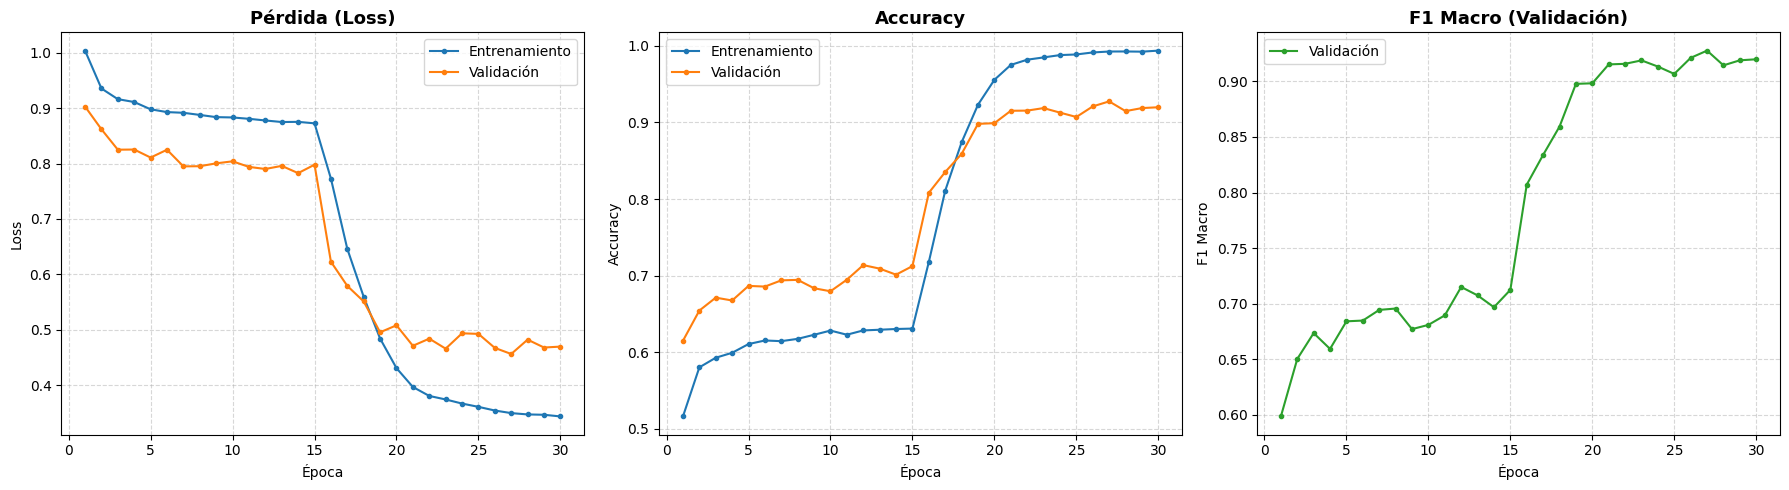

Mejor época según F1 macro de validación: 27 (F1 = 0.9276)


In [26]:
history_dict = {}
for h in (history_stage1.history, history_stage2.history):
    for k, v in h.items():
        history_dict.setdefault(k, []).extend(v)

if 'val_f1_score' in history_dict:
    f1_per_epoch = history_dict['val_f1_score']
else:
    f1_per_epoch = metrics_cb.history_f1

epochs_range = range(1, len(history_dict['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Perdida
axes[0].plot(epochs_range, history_dict['loss'], label='Entrenamiento', marker='o', markersize=3)
axes[0].plot(epochs_range, history_dict['val_loss'], label='Validación', marker='o', markersize=3)
axes[0].set_title('Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy
axes[1].plot(epochs_range, history_dict['accuracy'], label='Entrenamiento', marker='o', markersize=3)
axes[1].plot(epochs_range, history_dict['val_accuracy'], label='Validación', marker='o', markersize=3)
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# F1 macro (validación)
axes[2].plot(epochs_range, f1_per_epoch, label='Validación', color='#2ca02c', marker='o', markersize=3)
axes[2].set_title('F1 Macro (Validación)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('F1 Macro')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(f1_per_epoch)) + 1
print(f"Mejor época según F1 macro de validación: {best_epoch} (F1 = {max(f1_per_epoch):.4f})")


In [27]:
# Evaluación en el Conjunto de Validación
print("Conjunto de Validación:")

val_eval = model.evaluate(X_val, y_val_oh, verbose=0)
for name, value in zip(model.metrics_names, val_eval):
    print(f"  {name}: {value:.4f}")

y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
y_val_true = np.argmax(y_val_oh, axis=1)

val_acc = accuracy_score(y_val_true, y_val_pred)
val_f1_macro = f1_score(y_val_true, y_val_pred, average='macro')

print(f"\n  Accuracy: {val_acc:.4f}")
print(f"  F1 macro: {val_f1_macro:.4f}")

print("\nReporte de clasificación (Validación):")
print(classification_report(y_val_true, y_val_pred, target_names=encoder.classes_))

Conjunto de Validación:
  loss: 0.4565
  compile_metrics: 0.9275

  Accuracy: 0.9275
  F1 macro: 0.9276

Reporte de clasificación (Validación):
              precision    recall  f1-score   support

       Angry       0.91      0.92      0.92      1522
       Happy       0.96      0.95      0.95      1522
         Sad       0.91      0.92      0.91      1523

    accuracy                           0.93      4567
   macro avg       0.93      0.93      0.93      4567
weighted avg       0.93      0.93      0.93      4567



In [28]:
# Evaluación en el Conjunto de Prueba
print("Conjunto de Prueba:")

test_eval = model.evaluate(X_test, y_test_oh, verbose=0)
for name, value in zip(model.metrics_names, test_eval):
    print(f"  {name}: {value:.4f}")

y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_test_true = np.argmax(y_test_oh, axis=1)

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1_macro = f1_score(y_test_true, y_test_pred, average='macro')

print(f"\n  Accuracy: {test_acc:.4f}")
print(f"  F1 macro: {test_f1_macro:.4f}")

print("\nReporte de clasificación (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=encoder.classes_))


Conjunto de Prueba:
  loss: 0.4799
  compile_metrics: 0.9161

  Accuracy: 0.9161
  F1 macro: 0.9165

Reporte de clasificación (Test):
              precision    recall  f1-score   support

       Angry       0.90      0.91      0.90      1522
       Happy       0.97      0.93      0.95      1523
         Sad       0.88      0.92      0.90      1522

    accuracy                           0.92      4567
   macro avg       0.92      0.92      0.92      4567
weighted avg       0.92      0.92      0.92      4567



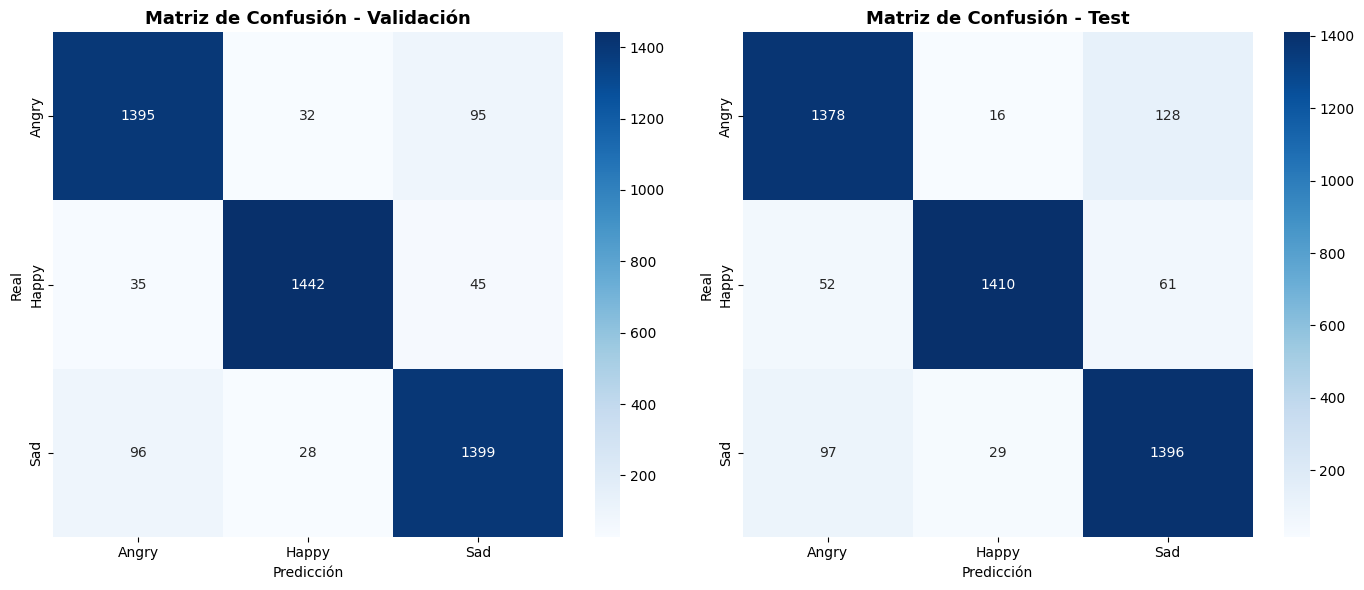

In [29]:
# Matriz de Confusión
cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusión - Validación', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=axes[1])
axes[1].set_title('Matriz de Confusión - Test', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [31]:
model.save("face2emotion_resnet50_final.keras")